# A two-line model for chunk read cost

Let $M$ be a set of selected weight rows, $\mathcal C(M)$ its maximal contiguous runs, and $q$ the row length in KiB. A table of chunk costs gives the additive estimate

$$L_{\mathrm{table}}(M)=\sum_{C\in\mathcal C(M)}T(q|C|).$$

We approximate $T$ by two continuous lines, with constant cost per KiB beyond a fitted boundary. We compare that boundary with two summaries of the measured curve and evaluate the approximation on held-out measurement blocks.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls
from IPython.display import Markdown, display

CSV_PATH = Path("block_estimates.csv")
SUBMODULE = Path("../../../upstream/vlm-flash")
RERUN_MEASUREMENTS = True
SIZES_KIB = np.r_[np.arange(1, 257), np.arange(260, 769, 4)]
BLOCKS, ITERS, WARMUP, THREADS, BLOB_MIB = 7, 10, 3, 6, 128

## From batch throughput to chunk cost

For length $z$ KiB and count $n_j$, let $u_{b,j}(z)$ be the median batch time in µs in block $b$. Logical data volume and throughput are

$$D_j(z)=\frac{n_jz}{1024}\ \mathrm{MiB},\qquad
\beta_{b,j}(z)=\frac{10^6D_j(z)}{u_{b,j}(z)}\ \mathrm{MiB/s}.$$

The profiler smooths throughput with a three-point mean. It averages the tail beginning at the first absolute slope below 5% of peak throughput per MiB; if none qualifies, it averages the last 20% of points. With fewer than three points it uses the last. The resulting $\widehat\beta_b(z)$ defines

$$\widehat T_b(z)=\frac{1000z}{1024\widehat\beta_b(z)}\quad\mathrm{ms/chunk}.$$

This is an amortized batch cost. Logical bytes exclude alignment padding; the estimator does not by itself certify saturation.

The grid $\mathcal G$ uses 1 KiB steps from 1 to 256 KiB and 4 KiB steps from 260 to 768 KiB. Acquisition randomizes size order in each of seven blocks, using a 128 MiB blob, six reader threads, three warmups and ten timed repetitions per count. Counts follow 1, 2, 4, 8, 16, 28, 32, 48, 64, 96, 128, 192, 256, 384 and 512, retaining those that fit the blob with 32 KiB gaps. The native profiler performs the reads; buffered I/O is rejected.

Run from this notebook's directory. By default, execution reads `block_estimates.csv`. Set `RERUN_MEASUREMENTS = True` to measure and write it, including when it is missing. Reacquisition requires the native profiler at `SUBMODULE` and the CSV directory on the target SSD.

In [5]:
def measure(directory):
    import sys
    from contextlib import redirect_stdout
    from io import StringIO
    from tempfile import TemporaryDirectory

    sys.path[:0] = [str((SUBMODULE / p).resolve()) for p in ("scripts", "src")]
    import profile_flash as profiler

    native_reader = profiler.native()
    if native_reader is None:
        raise RuntimeError(profiler.unavailable_reason())

    class DirectOnly:
        def read_rows(self, *args, **kwargs):
            result = native_reader.read_rows(*args, **kwargs)
            if not result[3]:
                raise RuntimeError("O_DIRECT unavailable; no latency profile was saved.")
            return result

    reader = DirectOnly()
    num_rows = BLOB_MIB * 1024 // profiler.ROW_KB
    rng, records = np.random.default_rng(0), []
    with profiler.exclusive("01_chunk_latency"), TemporaryDirectory(dir=directory) as work:
        blob = str(Path(work) / "profile_blob.dat")
        with redirect_stdout(StringIO()):
            profiler.prepare_blob(blob, num_rows)
            for block in range(BLOCKS):
                for order, size in enumerate(rng.permutation(SIZES_KIB)):
                    size = int(size)
                    runs = profiler.measure(reader, blob, num_rows, [size],
                                            ITERS, WARMUP, THREADS)[size]
                    rate = profiler.saturation_throughput(runs, size)
                    records.append(dict(block=block, order=order, size_kib=size,
                        latency_ms=1000 * size / (1024 * rate),
                        throughput_mib_s=rate, count_points=len(runs),
                        max_count=runs[-1][0]))
    return pd.DataFrame(records)

In [6]:
if RERUN_MEASUREMENTS:
    data = measure(CSV_PATH.parent)
    data.to_csv(CSV_PATH, index=False)
else:
    data = pd.read_csv(CSV_PATH)

The median over all seven blocks defines $T(z)$. Blocks 0–3 define $T_{\mathrm{train}}$ and blocks 4–6 define $T_{\mathrm{test}}$. The checks below require one observation per size per block, positive finite costs and the throughput identity above.

In [7]:
columns = {
    "block", "order", "size_kib", "latency_ms", "throughput_mib_s",
    "count_points", "max_count",
}
assert set(data) == columns, "The profile must use the seven-column schema."
assert len(data) == BLOCKS * len(SIZES_KIB), "The block grid is incomplete."
assert set(data.block) == set(range(BLOCKS))
assert set(data.size_kib) == set(SIZES_KIB)
assert not data.duplicated(["block", "size_kib"]).any()
assert not data.duplicated(["block", "order"]).any()
assert data.order.between(0, len(SIZES_KIB) - 1).all()
indices = data[["block", "order", "size_kib", "count_points", "max_count"]].to_numpy(float)
assert np.isfinite(indices).all() and (indices == np.floor(indices)).all()
values = data[["latency_ms", "throughput_mib_s", "count_points", "max_count"]].to_numpy(float)
assert np.isfinite(values).all() and (values > 0).all()
np.testing.assert_allclose(
    data.latency_ms, 1000 * data.size_kib / (1024 * data.throughput_mib_s),
    rtol=1e-9, atol=1e-12,
)

In [8]:
wide = data.pivot(index="size_kib", columns="block", values="latency_ms")
wide = wide.sort_index().sort_index(axis=1)
z, samples = wide.index.to_numpy(float), wide.to_numpy(float)
T = np.median(samples, axis=1)
T_train = np.median(samples[:, :4], axis=1)
T_test = np.median(samples[:, 4:], axis=1)

## Two summaries of the measured curve

The cost per KiB and its minimizing length are

$$\rho(z)=\frac{T(z)}z,\qquad z_{\rm eff}\in\arg\min_{z\in\mathcal G}\rho(z).$$

Since $\beta(z)=1000/(1024\rho(z))$, this also locates peak throughput. A second summary is the first size reaching 99% of the peak training throughput after a centered three-point median:

$$z_{99}=\min\left\{z\in\mathcal G:\widetilde\beta_{\mathrm{train}}(z)
\ge0.99\max_{u\in\mathcal G}\widetilde\beta_{\mathrm{train}}(u)\right\}.$$

Here smoothing uses adjacent grid points, with the available neighbors at each endpoint. A first crossing allows later sizes to fall below the threshold. We keep the full grid for fitting.

In [9]:
rho = T / z
z_eff = z[np.argmin(rho)]
B = 1000 * z / (1024 * T_train)
B_smooth = pd.Series(B).rolling(3, center=True, min_periods=1).median().to_numpy()
z_99 = z[np.flatnonzero(B_smooth >= .99 * B_smooth.max())[0]]

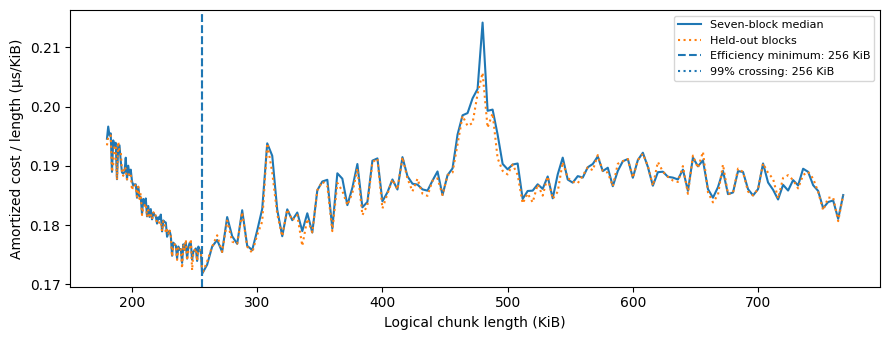

In [10]:
zoom = z >= 0.7 * min(z_eff, z_99)
plt.figure(figsize=(9, 3.5))
plt.plot(z[zoom], 1000 * rho[zoom], label="Seven-block median")
plt.plot(z[zoom], 1000 * T_test[zoom] / z[zoom], ":", label="Held-out blocks")
plt.axvline(z_eff, ls="--", label=f"Efficiency minimum: {z_eff:g} KiB")
plt.axvline(z_99, ls=":", label=f"99% crossing: {z_99:g} KiB")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Amortized cost / length (µs/KiB)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
below = np.sum(B_smooth[z > z_99] < .99 * B_smooth.max())
display(Markdown(
    f"**Figure 1.** Minimum cost per KiB: **{z_eff:g} KiB** "
    f"({1000 * rho.min():.4f} µs/KiB). The first 99% crossing is "
    f"**{z_99:g} KiB**; **{below}** later grid points fall below its threshold."))

**Figure 1.** Minimum cost per KiB: **256 KiB** (0.1718 µs/KiB). The first 99% crossing is **256 KiB**; **127** later grid points fall below its threshold.

## Fitting a constant-throughput tail

Consider the continuous family

$$T_{\rm 2L}(z;z_0)=c_1z+\delta\max(z_0,z)
=\begin{cases}\delta z_0+c_1z,&z\le z_0,\\(c_1+\delta)z,&z>z_0,\end{cases}
\qquad c_1,\delta\ge0.$$

The short-line intercept is $\delta z_0$. Beyond $z_0$, cost per KiB is fixed at $c_1+\delta$. For each candidate boundary, nonnegative least squares fits the coefficients to $T_{\mathrm{train}}$. The free fit chooses

$$z_{\rm 2L}\in\arg\min_{z_0\in\mathcal G^\circ}\min_{c_1,\delta\ge0}
\frac1{|\mathcal G|}\sum_{z\in\mathcal G}[T_{\mathrm{train}}(z)-T_{\rm 2L}(z;z_0)]^2,$$

where $\mathcal G^\circ$ excludes the first and last three grid sizes. Every measured size has equal weight, so the denser grid below 256 KiB contributes more observations.

For comparison, the hinge $T_H(z)=a+bz+d(z-z_H)_+$ allows a tail intercept $a-dz_H$, where $(x)_+=\max(x,0)$. Its coefficients are unconstrained and its boundary minimizes the same training loss. The affine baseline $T_A(z)=a+bz$ has no boundary.

In [12]:
def rmse(observed, predicted):
    return np.sqrt(np.mean((observed - predicted) ** 2))


def fit_two_line(boundary):
    X = np.column_stack((z, np.maximum(boundary, z)))
    coefficients = nnls(X, T_train)[0]
    return coefficients, X @ coefficients


two_line = {s: fit_two_line(s) for s in z}
z_candidates = z[3:-3]
E_two_line = np.array([rmse(T_train, two_line[s][1]) for s in z_candidates])
z_two_line = z_candidates[np.argmin(E_two_line)]
c1, delta = two_line[z_two_line][0]

In [13]:
def fit_hinge(boundary):
    X = np.column_stack((np.ones_like(z), z, np.maximum(z - boundary, 0)))
    coefficients = np.linalg.lstsq(X, T_train, rcond=None)[0]
    return coefficients, X @ coefficients


hinge = {s: fit_hinge(s) for s in z_candidates}
E_hinge = np.array([rmse(T_train, hinge[s][1]) for s in z_candidates])
z_hinge = z_candidates[np.argmin(E_hinge)]
ha, hb, hd = hinge[z_hinge][0]
band = z_candidates[E_two_line <= 1.01 * E_two_line.min()]

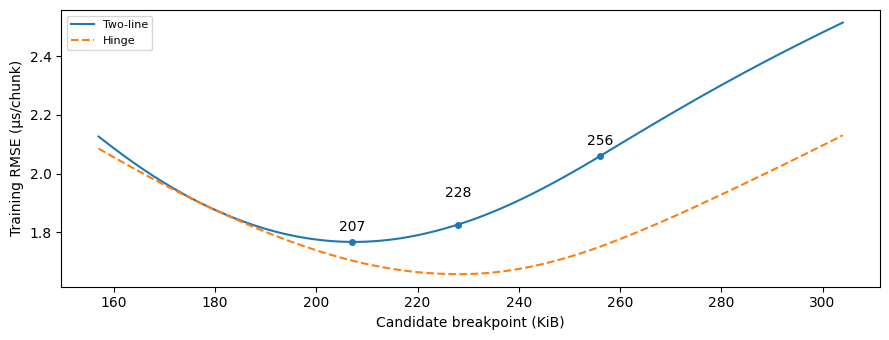

In [14]:
marked = sorted({z_eff, z_99, z_two_line, z_hinge})
local = (z_candidates >= min(marked) - 50) & (z_candidates <= max(marked) + 50)
plt.figure(figsize=(9, 3.5))
plt.plot(z_candidates[local], 1000 * E_two_line[local], label="Two-line")
plt.plot(z_candidates[local], 1000 * E_hinge[local], "--", label="Hinge")
for i, boundary in enumerate(marked):
    error = 1000 * rmse(T_train, two_line[boundary][1])
    plt.plot(boundary, error, "o", color="C0", ms=4)
    plt.annotate(f"{boundary:g}", (boundary, error), xytext=(0, 8 + 12 * (i % 2)),
                 textcoords="offset points", ha="center")
plt.xlabel("Candidate breakpoint (KiB)")
plt.ylabel("Training RMSE (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [15]:
display(Markdown(
    f"**Figure 2.** The two-line and hinge minima occur at **{z_two_line:g}** and "
    f"**{z_hinge:g} KiB**. The hinge tail intercept is "
    f"**{1000 * (ha - hd * z_hinge):.3f} µs**. Two-line candidates within 1% "
    f"of minimum RMSE span **{band.min():g}–{band.max():g} KiB**. "
    "This is a sensitivity range, not a confidence interval. Dots lie on the two-line curve."))

**Figure 2.** The two-line and hinge minima occur at **207** and **228 KiB**. The hinge tail intercept is **-2.526 µs**. Two-line candidates within 1% of minimum RMSE span **197–218 KiB**. This is a sensitivity range, not a confidence interval. Dots lie on the two-line curve.

## Fitted models

We also fit the two-line coefficients with the boundary fixed at $z_{\rm eff}$, $z_{99}$ or $z_H$. The equations show the free fits; the table includes every comparison. Displayed times are in µs and rounded, while predictions retain full precision in ms.

In [16]:
boundaries = {
    "Two-line (efficiency)": z_eff,
    "Two-line (99%)": z_99,
    "Two-line (hinge boundary)": z_hinge,
    "Two-line (free)": z_two_line,
}
predictions = {name: two_line[s][1] for name, s in boundaries.items()}
predictions["Hinge"] = hinge[z_hinge][1]
X_a = np.column_stack((np.ones_like(z), z))
aa, ab = np.linalg.lstsq(X_a, T_train, rcond=None)[0]
predictions["Affine"] = X_a @ [aa, ab]

In [17]:
display(Markdown(fr"""
With $z$ in KiB, the fitted costs in µs are

$$\widehat T_{{2L}}(z)=\begin{{cases}}
{1000*delta*z_two_line:.3f}+{1000*c1:.6f}z,&0<z\le {z_two_line:g},\\
{1000*(c1+delta):.6f}z,&z>{z_two_line:g},
\end{{cases}}$$

$$\widehat T_H(z)={1000*ha:.3f}{1000*hb:+.6f}z{1000*hd:+.6f}(z-{z_hinge:g})_+,$$
$$\widehat T_A(z)={1000*aa:.3f}{1000*ab:+.6f}z.$$
"""))


With $z$ in KiB, the fitted costs in µs are

$$\widehat T_{2L}(z)=\begin{cases}
12.196+0.128352z,&0<z\le 207,\\
0.187270z,&z>207,
\end{cases}$$

$$\widehat T_H(z)=12.273+0.127289z+0.064908(z-228)_+,$$
$$\widehat T_A(z)=6.470+0.174215z.$$


In [18]:
parameter_rows = []
for name, boundary in boundaries.items():
    c, d = two_line[boundary][0]
    parameter_rows.append([name, boundary, 1000*d*boundary, 1000*c, 0., 1000*(c+d)])
parameter_rows += [["Hinge", z_hinge, 1000*ha, 1000*hb,
                   1000*(ha-hd*z_hinge), 1000*(hb+hd)],
                  ["Affine", np.nan, 1000*aa, 1000*ab, 1000*aa, 1000*ab]]
parameters = pd.DataFrame(parameter_rows, columns=["Model", "Boundary (KiB)",
    "Short intercept (µs)", "Short slope (µs/KiB)", "Tail intercept (µs)",
    "Tail slope (µs/KiB)"]).set_index("Model")
parameters.round(6)

,Boundary (KiB),Short intercept (µs),Short slope (µs/KiB),Tail intercept (µs),Tail slope (µs/KiB)
Model,,,,,
Two-line (efficiency),256.0,10.808382,0.144317,0.000000,0.186537
Two-line (99%),256.0,10.808382,0.144317,0.000000,0.186537
Two-line (hinge boundary),228.0,11.604331,0.136056,0.000000,0.186952
Two-line (free),207.0,12.196012,0.128352,0.000000,0.187270
Hinge,228.0,12.273493,0.127289,-2.525535,0.192197
Affine,NaN,6.470158,0.174215,6.470158,0.174215


## Approximation error on held-out blocks

With the fitted curves frozen, evaluate

$$\mathrm{RMSE}=\sqrt{\frac1{|\mathcal G|}\sum_z[\widehat T(z)-T_{\mathrm{test}}(z)]^2},\qquad
\mathrm{MAPE}=\frac{100}{|\mathcal G|}\sum_z\frac{|\widehat T(z)-T_{\mathrm{test}}(z)|}{T_{\mathrm{test}}(z)}.$$

All coefficients, free boundaries and $z_{99}$ use training blocks only. The efficiency boundary $z_{\rm eff}$ uses all seven blocks, so its comparison is descriptive. These errors measure approximation to the held-out curve, not a change in SSD speed.

In [19]:
comparison = pd.DataFrame({name: {
    "Train RMSE (µs)": 1000 * rmse(T_train, prediction),
    "Holdout RMSE (µs)": 1000 * rmse(T_test, prediction),
    "Holdout MAPE (%)": 100 * np.mean(np.abs(prediction - T_test) / T_test),
} for name, prediction in predictions.items()}).T
comparison.index.name = "Model"
comparison.round(3)

,Train RMSE (µs),Holdout RMSE (µs),Holdout MAPE (%)
Model,,,
Two-line (efficiency),2.059,1.960,4.018
Two-line (99%),2.059,1.960,4.018
Two-line (hinge boundary),1.827,1.705,3.220
Two-line (free),1.767,1.632,2.878
Hinge,1.658,1.449,2.442
Affine,3.531,3.538,9.747


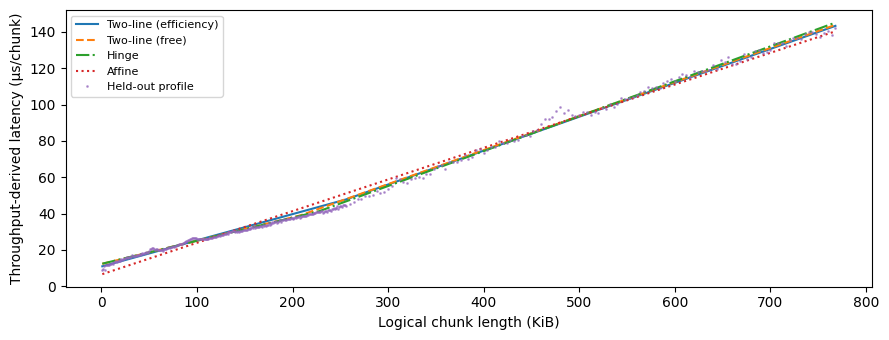

In [20]:
main_models = ["Two-line (efficiency)", "Two-line (free)", "Hinge"]
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models + ["Affine"], ["-", "--", "-.", ":"]):
    plt.plot(z, 1000 * predictions[name], style, label=name)
plt.plot(z, 1000 * T_test, ".", ms=2, alpha=.6, label="Held-out profile")
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Throughput-derived latency (µs/chunk)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [21]:
mape = comparison["Holdout MAPE (%)"]
display(Markdown(
    f"**Figure 3.** Holdout MAPE is **{mape['Two-line (free)']:.2f}%** "
    f"for the free two-line fit, **{mape['Hinge']:.2f}%** for the hinge "
    f"and **{mape['Affine']:.2f}%** for the affine baseline."))

**Figure 3.** Holdout MAPE is **2.88%** for the free two-line fit, **2.44%** for the hinge and **9.75%** for the affine baseline.

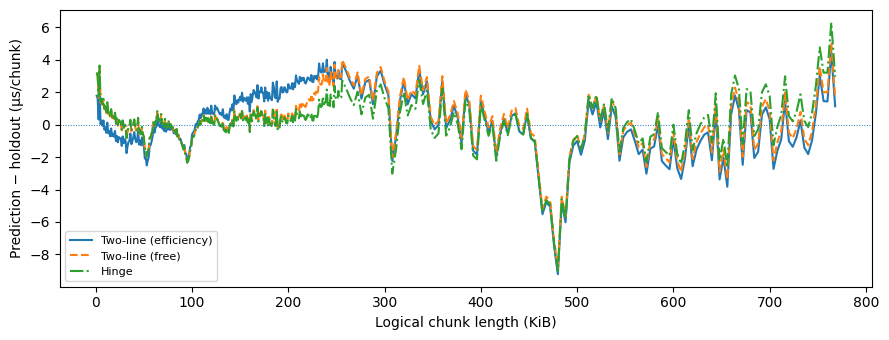

In [22]:
plt.figure(figsize=(9, 3.5))
for name, style in zip(main_models, ["-", "--", "-."]):
    plt.plot(z, 1000 * (predictions[name] - T_test), style, label=name)
plt.axhline(0, ls=":", lw=.7)
plt.xlabel("Logical chunk length (KiB)")
plt.ylabel("Prediction − holdout (µs/chunk)")
plt.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

**Figure 4.** Residuals are prediction minus held-out cost; negative values indicate underestimation.

## From the fitted curve to an additive cost

The fitted boundary minimizes approximation error. The efficiency minimum and throughput crossing describe the measured curve; neither is imposed on the free fit.

The two-line form has a useful decomposition:

$$T_{\rm 2L}(z)=(c_1+\delta)z+\delta(z_{\rm 2L}-z)_+.$$

Substituting each run's length $q|C|$ gives

$$\boxed{L_{\rm 2L}(M)=(c_1+\delta)q|M|
+\delta\sum_{C\in\mathcal C(M)}(z_{\rm 2L}-q|C|)_+.}$$

For a fixed number of selected rows, the first term is constant. The second charges for runs shorter than the fitted boundary. This structure motivates the two-line approximation; the holdout errors quantify its fit to the measured curve. Complete-mask latency and extrapolation beyond the measured lengths require separate validation.

The final cell exports the free two-line coefficients, grid and source CSV hash to `latency_model.json`.

In [23]:
import hashlib, json
from tempfile import NamedTemporaryFile

model = dict(format="vlm-in-flash-two-line-v1", unit=dict(length="KiB", time="ms"),
    csv_sha256=hashlib.sha256(CSV_PATH.read_bytes()).hexdigest(),
    fit_blocks=wide.columns[:4].tolist(), holdout_blocks=wide.columns[4:].tolist(),
    s_kib=float(z_two_line), c1_ms_per_kib=float(c1), delta_ms_per_kib=float(delta),
    s_eff_kib=float(z_eff), s99_kib=float(z_99), s_hinge_kib=float(z_hinge),
    measured_grid_kib=z.tolist(),
    fit="unweighted NNLS; free boundary on measured grid [3:-3]",
    acquisition_reference="9023679ebfd1900fa2912c4098f51bfb9efa7bb8")
model_path = CSV_PATH.with_name("latency_model.json")
with NamedTemporaryFile(mode="w", dir=model_path.parent, delete=False, encoding="utf-8") as f:
    json.dump(model, f, indent=2, allow_nan=False)
    f.write("\n")
Path(f.name).replace(model_path)

PosixPath('latency_model.json')